In [18]:
import importlib.util
spec = importlib.util.find_spec("vbfprocessor")
print(spec.origin)

import sys
sys.path.append('/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/')
print(sys.path)
import re
import json

/uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py
['/usr/local/lib', '/uscms_data/d3/azhou/smeft/analysis', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python311.zip', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11/lib-dynload', '', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11/site-packages', '/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/', '/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/']


In [62]:
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, PFNanoAODSchema
from coffea.processor import Runner, FuturesExecutor, IterativeExecutor

import hist
import vbfprocessor
import awkward as ak
import uproot

import os
import time

import coffea
print(coffea.__version__)
import matplotlib.pyplot as plt
import numpy as np

import boostedhiggs.ewk_higgs_correction as ewk

importlib.reload(ewk)
print("vbfprocessor path:", vbfprocessor.__file__)
importlib.reload(vbfprocessor)

from scipy.optimize import curve_fit

2025.10.2
vbfprocessor path: /uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py


In [46]:
def run_samp(sample):

    fileset = {}
    fileset[sample] = all_filesets[sample]
    outfile = "coffea/"+sample+".coffea"

    #processor that computes stuff like higgs, pt, histograms, etc
    p = vbfprocessor.VBFProcessor(isMC=True, ewkHcorr=True, systematics=True)

    #sets how coffea processes events
    executor = FuturesExecutor(workers=4, status=True)

    #create runner instance - this loops over files in fileset and feeds events into processor
    runner = Runner(
        executor=executor,
        savemetrics=True,
        schema=NanoAODSchema,
        chunksize=50000,
    )

    #run job
    output, metrics = runner(
        fileset=fileset,
        processor_instance=p,
        treename="Events",
    )

    util.save(output, outfile)
    print("saved " + outfile)


In [49]:
start0 = "/uscms/home/azhou/nobackup/smeft/cmseft/generation/CMSSW_13_2_9/src/start0_031726.root"
#vbf_rw_start0_5000, start0_022126, start0_022526, start0_031726
start1 = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start1_5000.root"

cHW_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHW_HT2/VBFH_SMEFTsim_100.root"
cHWtil_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHWtil_HT2/VBFH_SMEFTsim_101.root"

powheg_sample = "/uscms/home/jennetd/nobackup/hbb-prod-modes/eft/cmseft/generation/powheg-vbf/D59EF975-39CC-8B46-93D6-788FFA1EFE87.root"
powheg2_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/powheg.root"

all_filesets = {"start0": [start0],
          "start1": [start1],
               "cHW_sample": [cHW_sample],
               "cHWtil_sample": [cHWtil_sample],
               "powheg_sample": [powheg_sample],
               "powheg2_sample": [powheg2_sample]}

sample = "cHW_sample"
fileset = {sample: all_filesets[sample]}

run_samp("start0")

/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

HTXS sample: [205 209 202 209 205 213 204 209 223 215]
HTXS unique (first 20): [200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224]
adding EWK
hpt min & max: 0.8029667139053345 549.0679321289062
correction's min & max: 0.8097216216216215 0.8432930307941653
added VBF_EW
EWK applied
trying add_scalevar_3pt
type: 1828 * [var * float32[parameters={"__doc__": "LHE scale variation weights (w_var / w_nominal); [0] is MUF=\"0.5\" MUR=\"0.5\"; [1] is MUF=\"1.0\" MUR=\"0.5\"; [2] is MUF=\"2.0\" MUR=\"0.5\"; [3] is MUF=\"0.5\" MUR=\"1.0\"; [4] is MUF=\"2.0\" MUR=\"1.0\"; [5] is MUF=\"0.5\" MUR=\"2.0\"; [6] is MUF=\"1.0\" MUR=\"2.0\"; [7] is MUF=\"2.0\" MUR=\"2.0\"", "typename": "float[]"}], parameters={"__array__": "NanoCollection", "collection_name": "LHEScaleWeight"}]
LHEScaleWeight:  [[0.936, 1, 1.05, 0.936, 1.05, 0.936, 1, 1.05], ..., [0.942, 1, ..., 1, 1.04]]
variations: ['scalevar_3ptUp', 'scalevar_3ptDown']
avg weight before: 3.652909139053

saved coffea/start0.coffea


In [177]:
start0_events = NanoEventsFactory.from_root(
    {start0:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

In [178]:
f = uproot.open(start0)
print(f.keys())
runs_keys = list(f["Runs"].keys())
print("n Runs branches:", len(runs_keys))
print(runs_keys)

['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']
n Runs branches: 12
['run', 'genEventCount', 'genEventSumw', 'genEventSumw2', 'nLHEScaleSumw', 'LHEScaleSumw', 'nLHEPdfSumw', 'LHEPdfSumw', 'nPSSumw', 'PSSumw', 'nLHEReweightingSumw', 'LHEReweightingSumw']


In [179]:
W = start0_events.LHEReweightingWeight
g = start0_events.genWeight

K = int(ak.num(W, axis=1)[0])
print("K =", K)

f = uproot.open(start0)

print(f.keys())
#print("Events branches:", list(f["Events"].keys()))
#print("Runs branches:",   list(f["Runs"].keys()))

run_branches = list(f["Runs"].keys())
print(run_branches)

event_branches = list(f["Events"].keys())
chwtil_runs = [b for b in run_branches if "cHWtil" in b]
chwtil_events = [b for b in event_branches if "cHWtil" in b]

both = [b for b in run_branches if ("cHW_" in b and "cHWtil_" in b) and not "_cHW_0.0_" in b and not "_cHWtil_0.0_" in b]
print("# of mixed cHW, cHWtil points:", len(both))
print(both)


h = util.load("coffea/start0.coffea")["htxs"][{"wc": "SM"}]
print(h.axes)

f = uproot.open(start0)
print("Has Events.LHEReweightingWeight?",
      "LHEReweightingWeight" in f["Events"].keys())
print("Runs has LHEReweightingSumw?",
      "LHEReweightingSumw" in f["Runs"].keys())

K = 275
['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']
['run', 'genEventCount', 'genEventSumw', 'genEventSumw2', 'nLHEScaleSumw', 'LHEScaleSumw', 'nLHEPdfSumw', 'LHEPdfSumw', 'nPSSumw', 'PSSumw', 'nLHEReweightingSumw', 'LHEReweightingSumw']
# of mixed cHW, cHWtil points: 0
[]
(IntCategory([202, 209, 207, 200, 204, 213, 205, 210, 212, 215, 223, 219, 201, 208, 211, 217, 224, 206, 203, 216, 221, 214, 218, 222, 220], growth=True, name='htxs_stage2', label='HTXS stage1.2 code'),)
Has Events.LHEReweightingWeight? True
Runs has LHEReweightingSumw? True


In [75]:
def get_wc_order(reweight_card, dictionary_path='dictionary.json'):
    with open(dictionary_path) as f:
        d = json.load(f)
    order = []
    seen = set()
    with open(reweight_card) as f:
        for line in f:
            if line.startswith('set '):
                _, model, param_index, _ = line.split()
                name = d[model][param_index]
                if name not in seen:
                    order.append(name)
                    seen.add(name)
    return order
#print(get_wc_order('/uscms/home/azhou/nobackup/smeft/cmseft/generation/genproductions/bin/MadGraph5_aMCatNLO/cards/VBF_SMEFTsim_topU3l_NP1/VBF_SMEFTsim_topU3l_NP1_reweight_card.dat'))

def generate_tuples(n):
    values = [0.0, 0.5, 1.0]
    tuples = [()]
    for _ in range(n):
        tuples = [t + (v,) for t in tuples for v in values]
    return tuples

def wc_map_dict(unsorted_wc_list):
    
    wc_order = get_wc_order('/uscms/home/azhou/nobackup/smeft/cmseft/generation/genproductions/bin/MadGraph5_aMCatNLO/cards/VBF_SMEFTsim_topU3l_NP1/VBF_SMEFTsim_topU3l_NP1_reweight_card.dat')
    invalid_operators = [x for x in unsorted_wc_list if x not in wc_order]
    if invalid_operators:
        raise ValueError(f"Operators not found in wc_order built on reweight card (see path): {invalid_operators}.")
    
    wc_list = sorted(unsorted_wc_list, key=lambda x: wc_order.index(x))
    
    point_list = generate_tuples(len(wc_list))
    wc_map = {}
    for point in point_list:
        non_sm_points = [(wc_list[i], point[i]) for i in range(len(point)) if point[i] != 0.0]
        if not non_sm_points:
            name = "SM"
        else:
            name = ",".join(f"{wc}={val}" for wc, val in non_sm_points)
        wc_map[point] = name
    
    return wc_map

def get_bin_yields(hslice):
    bin1_codes = [221, 222]
    bin2_codes = [223, 224]
    
    axis = hslice.axes["htxs_stage2"]
    values = hslice.values()
    codes = [axis.bin(i) for i in range(axis.size)]
    code_to_value = {code: values[i] for i, code in enumerate(codes)}
    bin1 = sum(code_to_value.get(c, 0.0) for c in bin1_codes)
    bin2 = sum(code_to_value.get(c, 0.0) for c in bin2_codes)
    return bin1, bin2

def quad_2D(xdata, a1, a2, b1, b2, c, d):
    x1, x2 = xdata
    return a1*x1*x1 + a2*x1 + b1*x2*x2 + b2*x2 + c*x1*x2 + d

def stxs_reweight_function(coffea_name, operator_list):
    
    bin1_codes = [221, 222]
    bin2_codes = [223, 224]

    bin1_yield_list = {}
    bin2_yield_list = {}

    all_h = util.load(f"coffea/{coffea_name}.coffea")["htxs"]
    
    wc_mapping = wc_map_dict(operator_list)
    print('wc_mapping:', wc_mapping)

    for p, wc_label in wc_mapping.items():
        if wc_label not in list(all_h.axes["wc"]):
            continue
        hslice = all_h[{"wc": wc_label}]
        bin1, bin2 = get_bin_yields(hslice)
        bin1_yield_list[p] = bin1
        bin2_yield_list[p] = bin2

    print('bin1 yield dict: ', bin1_yield_list)
    print('bin2 yield dict: ',bin2_yield_list)

    points = wc_mapping.keys()
    points = [point for point in points if point in bin1_yield_list.keys()]
    y_bin1 = np.array([bin1_yield_list[point] for point in points])
    y_bin2 = np.array([bin2_yield_list[point] for point in points])

    op1_vals = np.array([point[0] for point in points])
    op2_vals = np.array([point[1] for point in points])

    if len(operator_list) == 2:
        fit_dim = int(((len(operator_list) + 1) * (len(operator_list) + 2))/2)
        print('fit_dim:', fit_dim)
        p0 = list(np.ones(fit_dim, dtype=float)) #initial guess
        print(p0)
        
        coeff_bin1, cov_bin1 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin1, p0=p0)
        coeff_bin2, cov_bin2 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin2, p0=p0)

    print('coeff_bin1: ', coeff_bin1)
    print('coeff_bin2: ', coeff_bin2)

stxs_reweight_function('start0', ['cHW', 'cHWtil'])

wc_mapping: {(0.0, 0.0): 'SM', (0.0, 0.5): 'cHWtil=0.5', (0.0, 1.0): 'cHWtil=1.0', (0.5, 0.0): 'cHW=0.5', (0.5, 0.5): 'cHW=0.5,cHWtil=0.5', (0.5, 1.0): 'cHW=0.5,cHWtil=1.0', (1.0, 0.0): 'cHW=1.0', (1.0, 0.5): 'cHW=1.0,cHWtil=0.5', (1.0, 1.0): 'cHW=1.0,cHWtil=1.0'}
bin1 yield dict:  {(0.0, 0.0): np.float64(43.221195387112715), (0.0, 0.5): np.float64(47.73313876194014), (0.0, 1.0): np.float64(57.047136216062256), (0.5, 0.0): np.float64(51.76284404605856), (1.0, 0.0): np.float64(62.659766716850534), (1.0, 1.0): np.float64(69.91571407563802)}
bin2 yield dict:  {(0.0, 0.0): np.float64(49.27274963091707), (0.0, 0.5): np.float64(45.1351863437841), (0.0, 1.0): np.float64(46.55737523750485), (0.5, 0.0): np.float64(52.474979525822434), (1.0, 0.0): np.float64(58.281833283091586), (1.0, 1.0): np.float64(64.45824706537778)}
fit_dim: 6
[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
coeff_bin1:  [ 4.71054802 14.72802331  9.60410816  4.22183267 -

/tmp/ipykernel_8782/627285462.py:80: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin1, cov_bin1 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin1, p0=p0)
/tmp/ipykernel_8782/627285462.py:81: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin2, cov_bin2 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin2, p0=p0)


['run', 'genEventCount', 'genEventSumw', 'genEventSumw2', 'nLHEScaleSumw', 'LHEScaleSumw', 'nLHEPdfSumw', 'LHEPdfSumw', 'nPSSumw', 'PSSumw', 'nLHEReweightingSumw', 'LHEReweightingSumw']
<TBranch 'genEventSumw' at 0x7f4e0d875dd0>
[6.68e+03]
6677.5166015625
chwevents [43.22119539 44.7411032  46.35522197 48.0635517  49.8660924  51.76284405
 53.75380666 55.83898024 58.01836477 60.29196027]
[6.68e+03]
23.262681488937275
23.262681488937275


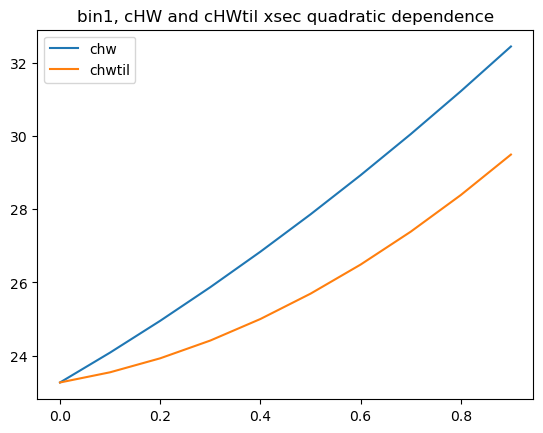

In [168]:
def plot_1D(coeff1, coeff2, coeff3, x_point):
    value = coeff1 * (x_point**2) + coeff2 * (x_point) + coeff3
    return value

x_chw_vals = np.arange(0, 1, 0.1)
y_chw_vals = np.array([plot_1D(4.71054802, 14.72802331, 43.22119539, x) for x in x_chw_vals])

x_chwtil_vals = np.arange(0, 1, 0.1)
y_chwtil_vals = np.array([plot_1D(9.60410816 , 4.22183267, 43.22119539, x) for x in x_chwtil_vals])

###

h = uproot.open(start0)["Runs"]
print(h.keys())
sumw = h['genEventSumw']
print(sumw)
sumw = h["genEventSumw"].array()
print(sumw)
sumw_all_noEW = h_coffea["sumw_all_noEW"].value
print(sumw_all_noEW)

chw_events = y_chw_vals
chwtil_events = y_chwtil_vals

start0_MG_sigma = 3.594
chw_xs_fb = start0_MG_sigma * 1000.0 * (chw_events / sumw)
chwtil_xs_fb = start0_MG_sigma * 1000.0 * (chwtil_events / sumw)

print('chwevents', chw_events)
print(sumw)

plt.title('bin1, cHW and cHWtil xsec quadratic dependence')

plt.plot(x_chw_vals, chw_xs_fb, label = 'chw')
plt.plot(x_chwtil_vals, chwtil_xs_fb, label = 'chwtil')
plt.legend()

print(chw_xs_fb[0])
print(chwtil_xs_fb[0])

(100, 100)
SM xsec: 23.262681487383272


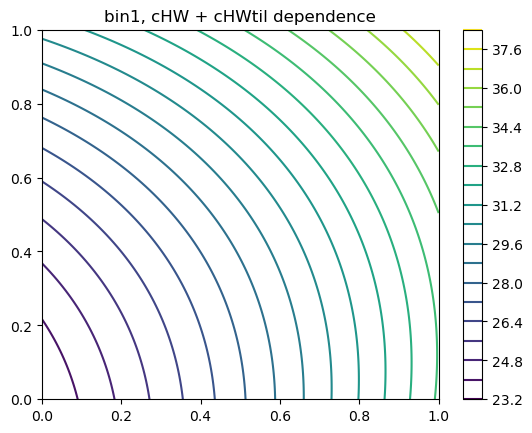

In [165]:
x1_vals = np.linspace(0, 1, 100)
x2_vals = np.linspace(0, 1, 100)

X1, X2 = np.meshgrid(x1_vals, x2_vals)

Z = quad_2D((X1,X2), *coeff_bin1)
print(Z.shape)

Z_xs_fb = start0_MG_sigma * 1000.0 * (Z / sumw)
print("SM xsec:", Z_xs_fb[0, 0])

fig, ax = plt.subplots()
contourplot = plt.contour(x1_vals, x2_vals, Z_xs_fb, levels = 20)

plt.title('bin1, cHW + cHWtil dependence')

cbar = fig.colorbar(contourplot)

def wc_from_name(name):
    #creates dict of wc values from names
    wc = {}
    parts = name.split("_")
    for index, p in enumerate(parts): 
        if p.startswith("c") and index+ 1 < len(parts): #length check to prevent crash at end of parts list
            try:
                wc[p] = float(parts[index+1]) #adds the corresponding value for a given operator (the next part)
            except:
                pass
    return wc

def sample_to_benchmarks(events_root):
    benchmarks = []
    
    f = uproot.open(events_root)
    run_branches = list(f["Runs"].keys())
    
    for k, b in enumerate(run_branches):
        if b.startswith("LHESumw_EFTrwgt"):
            wc = wc_from_name(b)
            benchmarks.append({"index": k,
                               "name": b,
                               "wc": wc})
    return(benchmarks)

def get_2Dfit_points(events_root):
    #returns a list of dicts, one for each benchmark point
    fit_points = []
    
    benchmarks = sample_to_benchmarks(events_root)

    sample_events = NanoEventsFactory.from_root(
        {events_root:"/Events"},
        schemaclass=PFNanoAODSchema,
        mode='eager'
        ).events()
    
    genWeights = sample_events.genWeight
    LHEReweightingWeights = sample_events.LHEReweightingWeight

    for k, bm in enumerate(benchmarks):

        # bin1_mask = 
        # bin2_mask = 
        
        # Y1 = ak.sum(
        #     genWeights[bin1_mask] * LHEReweightingWeights[bin1_mask][:, k]
        # )
        # Y2 = ak.sum(
        #     genWeights[bin2_mask] * LHEReweightingWeights[bin2_mask][:, k]
        # )
        
        bin_yields = {"bin1": 'y1_value', "bin2": 'y2_value'}
        
        point_dict = {"benchmark_index": k,
                      "wc_name": bm['name'],
                      "wc_point": bm['wc'],
                      "yields": bin_yields
                     }
        
        fit_points.append(point_dict)
    return fit_points

print(get_2Dfit_points("/uscms/home/azhou/nobackup/smeft/jennet_files/start0_022526.root"))

def parse_wc_from_name(name):
    #creates dict of wc values from names
    wc = {}
    parts = name.split("_")
    for index, p in enumerate(parts): 
        if p.startswith("c") and index+ 1 < len(parts): #length check to prevent crash at end of parts list
            try:
                wc[p] = float(parts[index+1]) #adds the corresponding value for a given operator (the next part)
            except:
                pass
    return wc


def sample_to_benchmarks(run_branches):
    benchmarks = []
    
    for b in run_branches:
        if b.startswith("LHESumw_EFTrwgt"):
            wc = parse_wc_from_name(b)
            benchmarks.append({
                "name": b,
                "wc": wc
            })
    return(benchmarks)
    print(benchmarks)

#def unique_benchmark_points():
    
sorted(set([bm["wc"]["cHW"] for bm in benchmarks]))
#sorted(set([bm["wc"]["cHWtil"] for bm in benchmarks]))
list_of_cHW_values = sorted(
    set(
        bm["wc"]["cHW"]
        for bm in benchmarks
        if bm["wc"].get("cHW", 0.0) != 0.0
    )
)
#print(list_of_cHW_values)
#print(sorted(set(bm["wc"]["cHW"] for bm in benchmarks)))